# this is a mini MVA project 

In [15]:
import pandas as pd 
import numpy as np
import pingouin as pg
import plotly.express as px
import matplotlib.pyplot as plt  
from sklearn.preprocessing import MinMaxScaler

In [16]:
df = pd.read_csv('/mnt/78AA22ECAA22A71A/K_REPO/project555/data/HATCO_clean.csv')
df.head()

,id,delivery_speed,price_level,price_flexibility,manufacturer_image,service_level,salesforce_image,product_quality,firm_size,usage_level,satisfaction,spec_buying,procurement_structure,industry_type,buying_situation
0,1,4.1,0.6,6.9,4.7,2.4,2.3,5.2,0,32,4.2,1,0,1,1
1,2,1.8,3.0,6.3,6.6,2.5,4.0,8.4,1,43,4.3,0,1,0,1
2,3,3.4,5.2,5.7,6.0,4.3,2.7,8.2,1,48,5.2,0,1,1,2
3,4,2.7,1.0,7.1,5.9,1.8,2.3,7.8,0,32,3.9,0,1,1,1
4,5,6.0,0.9,9.6,7.8,3.4,4.6,4.5,2,58,6.8,1,0,1,3


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     100 non-null    int64  
 1   delivery_speed         100 non-null    float64
 2   price_level            100 non-null    float64
 3   price_flexibility      100 non-null    float64
 4   manufacturer_image     100 non-null    float64
 5   service_level          100 non-null    float64
 6   salesforce_image       100 non-null    float64
 7   product_quality        100 non-null    float64
 8   firm_size              100 non-null    int64  
 9   usage_level            100 non-null    int64  
 10  satisfaction           100 non-null    float64
 11  spec_buying            100 non-null    int64  
 12  procurement_structure  100 non-null    int64  
 13  industry_type          100 non-null    int64  
 14  buying_situation       100 non-null    int64  
dtypes: floa

## report the raw data stats

In [18]:
from ydata_profiling import ProfileReport

#profile = ProfileReport(df, title="Profiling Report")
#profile.to_file("your_report.html")

### data is clean and ready for the tests

## 1st question: Does the price level affect the firm size?

### 📌 RQ1: Price Level vs. Firm Size

**Question:** Does the average firm size (`firm_size`) differ significantly by price level (`price_level`)?

**Test:** One-Way ANOVA

**Variables:**
* **DV:** `firm_size` [0 = Small, 1 = Medium, 2 = Large]
* **IV:** `price_level` [Continous(0-10)]

**Hypotheses:**
* **$H_0$:** $\mu_{Low} = \mu_{Medium} = \mu_{High}$ — The mean firm size is **equal** across all price level groups (No difference)
* **$H_1$:** At least one group's mean firm size differs — The mean firm size is **not equal** across all price level groups (Difference exists)

**Steps:**
1. **Categorize IV:** Bin `price_level` into 3 groups (Low, Medium, High).
2. **Normality:** Shapiro-Wilk Test for each segment (each price_level group).
3. **Homogeneity of Variance:** Levene's Test.
4. **Execution:** Run One-Way ANOVA and evaluate the *P-value*.

In [19]:
IV = "firm_size"
DV = "price_level"

### step1 test Ho: all segments in normal.dist  

In [43]:
G_0_price = df.loc[df[IV] == 0, DV]
G_1_price = df.loc[df[IV] == 1, DV]
G_2_price = df.loc[df[IV] == 2, DV]
price_groupes= [G_0_price,G_1_price,G_2_price]

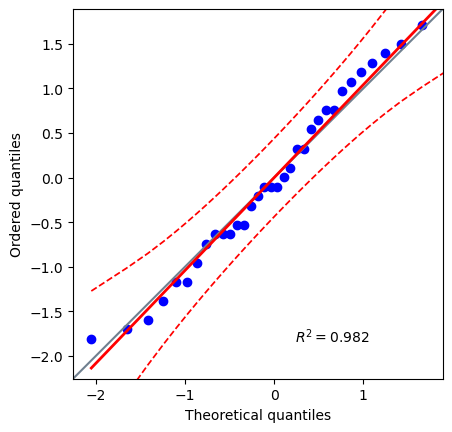

                    W      pval  normal
price_level  0.967914  0.406398    True


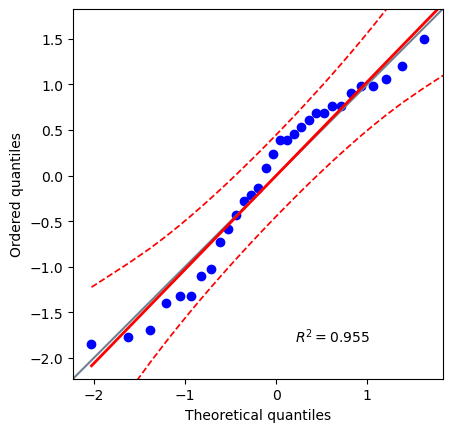

                    W      pval  normal
price_level  0.941633  0.083303    True


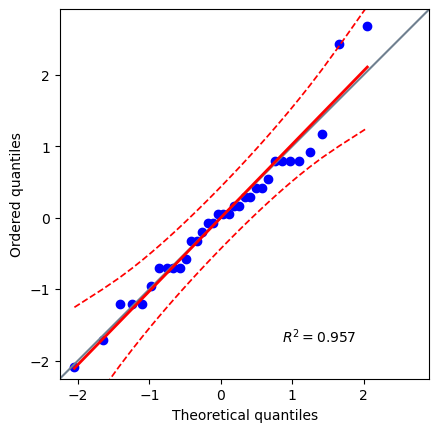

                    W      pval  normal
price_level  0.963491  0.306469    True


In [42]:
for i in price_groupes:
    ax = pg.qqplot(i, dist='norm')
    plt.show()
    print(pg.normality(i))

#### step 2 , Levens's test(homogenty of variance) , Ho: price level devided by segments variances are equal 

In [22]:
Levens_test= pg.homoscedasticity(data=df, dv=DV, group=IV)
print(Levens_test)

               W      pval  equal_var
levene  1.597625  0.207655       True


#### accept H0

#### Anova test
**$H_0$:** $\mu_{Low} = \mu_{Medium} = \mu_{High}$ (No difference in mean firm size across price level groups)

**$H_1$:** At least one mean differs (Difference exists)

In [23]:
#H0: mean firm_size is equal across Low, Medium, and High price_level groups
pg.anova(data=df, dv=DV, between=IV, detailed=False)

,Source,ddof1,ddof2,F,p_unc,np2
0,firm_size,2,97,5.136595,0.007579,0.095767


#### reject H0, P-value < .05

#### We go for the post-hoc test(Tukey-HSD)
H0: price_level Mu, Small = price_level Mu, Medium
Ha: price_level Mu, Small =! price_level Mu, Medium

-------------------------------------------------

H0: price_level Mu, Small = price_level Mu, Large
Ha: price_level Mu, Small =! price_level Mu, Large

-------------------------------------------------

H0: price_level Mu, Medium = price_level Mu, Large
Ha: price_level Mu, Medium =! price_level Mu, Large

In [24]:
tukey_results = pg.pairwise_tukey(data=df, dv=DV, between=IV)
print(tukey_results)

   A  B    mean_A    mean_B      diff        se         T   p_tukey    hedges
0  0  1  2.006667  2.828947 -0.822281  0.280531 -2.931155  0.011630 -0.688980
1  0  2  2.006667  2.146875 -0.140208  0.291904 -0.480324  0.880761 -0.131352
2  1  2  2.828947  2.146875  0.682072  0.275589  2.474964  0.039610  0.563548


#### we reject the H0 of cases (0,1) , (1,2) and accept Ha
Ha: price_level Mu, Small =! price_level Mu, Medium at P-value(0.012)
Ha: price_level Mu, Medium =! price_level Mu, Large at P-value(0.4)
for case (0,2) we accept H0: price_level Mu, Small = price_level Mu, Large
 at P-value(0.8)

### 📊 One-Way ANOVA Result

*(Run the cells above to see results)*

**Evaluate:** Check the F-statistic, p-value, and effect size (np²) to determine if firm size significantly affects price level.

**Conclusion:**
<span style="color:red">Reject H₀ (at least one price level group has a significantly different mean firm size).</span>


### *************************************************************************

### 📌 RQ: Buying Situation vs. Corporate Image Perceptions

**Question:** Do the average perceptions of the company (i.e., `salesforce_image` and `manufacturer_image`) differ significantly based on the `buying_situation`?

**Test:** One-Way MANOVA (Multivariate Analysis of Variance)

**Variables:**
* **IV:** `buying_situation` [Categorical: New, Modified, Straight]
* **DVs:** `salesforce_image`, `manufacturer_image` [Continuous]

**Hypotheses:**
* **$H_0$:** $\boldsymbol{\mu}_{New} = \boldsymbol{\mu}_{Modified} = \boldsymbol{\mu}_{Straight}$ (No difference in the *mean vectors* across groups)
* **$H_1$:** At least one group mean vector differs (Buying situation affects at least one of the images)

**Steps:**
1. **Normality:** Shapiro-Wilk test for each DV.
2. **Homogeneity of Covariance Matrices:** Box's M Test.
3. **Homoscedasticity:** Levene's Test (for each DV individually).
4. **Execution:** Run MANOVA and evaluate the *P-value* using both **Wilks' Lambda** and **Pillai's Trace**. *(If P-value > 0.05, we Accept $H_0$ and no Post-Hoc is needed).*

In [25]:
IV = "buying_situation"
DVs = ["salesforce_image" , "manufacturer_image"]

In [44]:
G_1_buying = df.loc[df[IV] == 1, DVs]
G_2_buying = df.loc[df[IV] == 2, DVs]
G_3_buying = df.loc[df[IV] == 3, DVs]
buying_groupes= [G_1_buying,G_2_buying,G_3_buying]

In [49]:
print(G_2_buying.head())

    salesforce_image  manufacturer_image
2                2.7                 6.0
5                1.9                 4.8
7                2.2                 5.1
9                3.2                 6.0
11               2.5                 4.6


### test normality 

In [66]:
k = 1 
for i in buying_groupes:
    print(f'--- For segment {k} ---')
    print(pg.normality(i))
    print("\n"*2)
    k += 1

--- For segment 1 ---
                           W      pval  normal
salesforce_image    0.962422  0.285677    True
manufacturer_image  0.954676  0.169391    True



--- For segment 2 ---
                           W      pval  normal
salesforce_image    0.944962  0.103606    True
manufacturer_image  0.940507  0.077390    True



--- For segment 3 ---
                           W      pval  normal
salesforce_image    0.956338  0.189780    True
manufacturer_image  0.969378  0.444537    True





#### all DVs segmented by the IV(1,2,3) are in normal.dist

### test Homogeneity of Covariance Matrices (Covariance):
Hypothesis
H0:
DVs Covariance, New = DVs Covariance, Modified = DVs Covariance, Straight
Ha:
At least DVs Covariance of TWO group are NOT Equal.

In [68]:
box_m_result = pg.box_m(data=df, dvs=DVs, group=IV)
print(box_m_result)

          Chi2   df      pval  equal_cov
box  12.506458  6.0  0.051578       True


#### accept the H0 the covariance of DVs in the 3 segments are equal can go for manova instead of mancova

### test the homoscedastisty of each DV alone
Hypothesis
H0:
Combined DVs Sig2, New = Combined DVs Sig2, Modified = Combined DVs Sig2, Straight
Ha:
At least Combined DVs Sig2 of TWO group are NOT Equal.

In [69]:
for i in DVs:
    print(f"{i} homoscedasticity result: \n {pg.homoscedasticity(data=df, dv=i, group=IV)} \n\n")

salesforce_image homoscedasticity result: 
                W      pval  equal_var
levene  1.779353  0.174211       True 


manufacturer_image homoscedasticity result: 
                W      pval  equal_var
levene  1.999337  0.140968       True 




### run the manova test
Hypothesis
H0:
Combined DVs Mu, New = Combined DVs Mu, Modified = Combined DVs Mu, Straight
Ha:
At least TWO Combined DVs Mu are NOT Equal

In [33]:
from statsmodels.multivariate.manova import MANOVA
from IPython.display import display

In [70]:
manova = MANOVA.from_formula('salesforce_image + manufacturer_image ~ C(buying_situation)', data=df)
results = manova.mv_test()
print(results)

                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value  Num DF  Den DF F Value  Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.1256 2.0000 96.0000 334.1552 0.0000
         Pillai's trace 0.8744 2.0000 96.0000 334.1552 0.0000
 Hotelling-Lawley trace 6.9616 2.0000 96.0000 334.1552 0.0000
    Roy's greatest root 6.9616 2.0000 96.0000 334.1552 0.0000
-------------------------------------------------------------
                                                             
-------------------------------------------------------------
  C(buying_situation)   Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.9133 4.0000 192.0000  2.2265 0.0676
         Pillai's trace 0.0867 4.0000 194.0000  2.1977 0.0707
 Hotelling-Lawley trace 0.

#### P-Values for BOTH Wilks' Lambda and Pillai’s > 0.05 So, We Accept H0

### 💡 Analytical Note: Interpreting MANOVA Test Statistics

**Observation:** In the `buying_situation` results, the multivariate test statistics (e.g., Wilks' Lambda, Pillai's Trace) consistently indicate a non-significant result ($p > 0.05$). 

**Why are the F-values different?**
Unlike scenarios where an independent variable has exactly two groups (which causes all four test statistics to converge mathematically), the $F$-values here vary. This divergence confirms that the independent variable (`buying_situation`) consists of **three groups** (New task, Modified re-buy, and Straight re-buy). 

**🎯 Final Conclusion:** We **Accept the null hypothesis ($H_0$)**. There is NO statistically significant multivariate effect of the buying situation on the combined corporate image perceptions (`salesforce_image` and `manufacturer_image`). Clients in different buying situations do not perceive HATCO's overall corporate image fundamentally differently. Therefore, **NO Post-Hoc test is needed**.